# UAV GenAI Environment - DQL and GDQL Analysis

This notebook analyzes the results from UAV GenAI environment experiments for DQL and GDQL models with different user equipment (UE) configurations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import json

# Base directory
base_dir = "/home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results"
uav_dir = os.path.join(base_dir, "uav-genai-env|exp_1")

print(f"Base directory: {base_dir}")
print(f"UAV GenAI directory: {uav_dir}")

Base directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results
UAV GenAI directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1


In [2]:
# Define DQL and GDQL model directories
dql_dir = os.path.join(uav_dir, "diffusion-dql|T-5")
gdql_dir = os.path.join(uav_dir, "diffusion-gdql|T-5")

# UE configurations to analyze
ue_configs = ["5_ues/43", "7_ues/43", "9_ues/43"]

# Store paths for DQL and GDQL models
dql_paths = {}
gdql_paths = {}

print("=== DQL Model Paths ===")
for ue_config in ue_configs:
    dql_path = os.path.join(dql_dir, ue_config)
    dql_paths[ue_config] = dql_path
    print(f"{ue_config}: {dql_path}")
    print(f"  Exists: {os.path.exists(dql_path)}")
    if os.path.exists(dql_path):
        files = os.listdir(dql_path)
        print(f"  Files: {files}")
    print()

print("=== GDQL Model Paths ===")
for ue_config in ue_configs:
    gdql_path = os.path.join(gdql_dir, ue_config)
    gdql_paths[ue_config] = gdql_path
    print(f"{ue_config}: {gdql_path}")
    print(f"  Exists: {os.path.exists(gdql_path)}")
    if os.path.exists(gdql_path):
        files = os.listdir(gdql_path)
        print(f"  Files: {files}")
    print()

=== DQL Model Paths ===
5_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/5_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

7_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/7_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

9_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/9_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

=== GDQL Model Paths ===
5_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion

In [3]:
# Load epoch rewards data for plotting convergence
def load_epoch_rewards(model_paths, model_name):
    """Load epoch rewards for all UE configurations"""
    rewards_data = {}
    
    for ue_config, path in model_paths.items():
        rewards_file = os.path.join(path, 'epoch_rewards.npy')
        if os.path.exists(rewards_file):
            rewards = np.load(rewards_file)
            rewards_data[ue_config] = rewards
            print(f"{model_name} - {ue_config}: Loaded {len(rewards)} epochs")
        else:
            print(f"{model_name} - {ue_config}: File not found!")
    
    return rewards_data

# Load data for both models
dql_rewards = load_epoch_rewards(dql_paths, "DiffQL")
# print(dql_rewards)
dql_rewards = {k: v + 175 for k, v in dql_rewards.items()}
gdql_rewards = load_epoch_rewards(gdql_paths, "DQL")

DiffQL - 5_ues/43: Loaded 500 epochs
DiffQL - 7_ues/43: Loaded 500 epochs
DiffQL - 9_ues/43: Loaded 500 epochs
DQL - 5_ues/43: Loaded 500 epochs
DQL - 7_ues/43: Loaded 500 epochs
DQL - 9_ues/43: Loaded 500 epochs


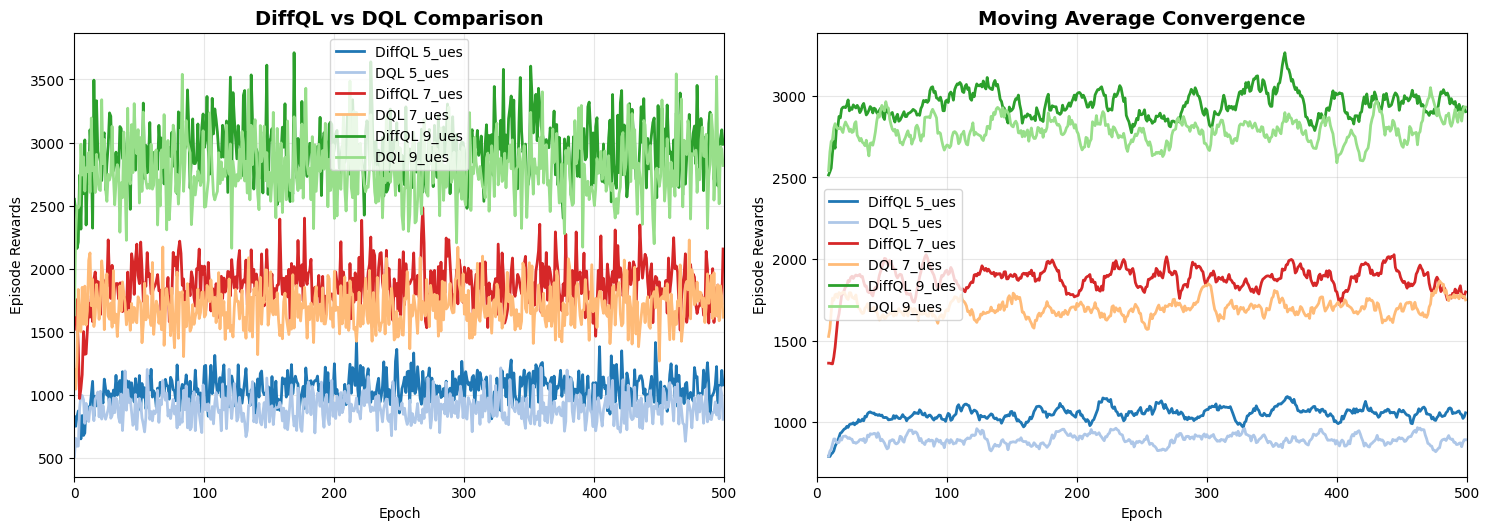


=== Convergence Statistics ===

DiffQL Model:
  5_ues:
    Final reward: 1078.88
    Max reward: 1431.00
    Mean reward: 1046.48
    Std reward: 114.10
    Epochs: 500
  7_ues:
    Final reward: 2156.58
    Max reward: 2483.83
    Mean reward: 1870.44
    Std reward: 185.88
    Epochs: 500
  9_ues:
    Final reward: 2986.28
    Max reward: 3712.30
    Mean reward: 2942.51
    Std reward: 233.20
    Epochs: 500

DQL Model:
  5_ues:
    Final reward: 806.04
    Max reward: 1218.81
    Mean reward: 891.58
    Std reward: 110.80
    Epochs: 500
  7_ues:
    Final reward: 1615.70
    Max reward: 2227.92
    Mean reward: 1697.36
    Std reward: 169.68
    Epochs: 500
  9_ues:
    Final reward: 2818.13
    Max reward: 3544.63
    Mean reward: 2785.12
    Std reward: 249.18
    Epochs: 500


In [4]:
# Plot convergence curves
plt.figure(figsize=(15, 10))

# Define colors for different UE configurations
# DQL uses darker colors, GDQL uses lighter/pastel colors
colors_dql = {'5_ues/43': '#1f77b4', '7_ues/43': '#d62728', '9_ues/43': '#2ca02c'}  # Dark blue, red, green
colors_gdql = {'5_ues/43': '#aec7e8', '7_ues/43': '#ffbb78', '9_ues/43': '#98df8a'}  # Light blue, orange, light green
line_style = '-'  # Use solid lines for both

# # Plot DQL results
# plt.subplot(2, 2, 1)
# for ue_config, rewards in dql_rewards.items():
#     ue_name = ue_config.split('/')[0]  # Extract UE configuration name
#     plt.plot(rewards, color=colors_dql[ue_config], linestyle=line_style, 
#              label=f'DiffQL {ue_name}', linewidth=2)
# plt.title('DiffQL Model Convergence', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.xlim(0, 500)  # Set x-axis limit for consistency
# plt.ylabel('Episode Rewards')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Plot GDQL results
# plt.subplot(2, 2, 2)
# for ue_config, rewards in gdql_rewards.items():
#     ue_name = ue_config.split('/')[0]  # Extract UE configuration name
#     plt.plot(rewards, color=colors_gdql[ue_config], linestyle=line_style, 
#              label=f'DQL {ue_name}', linewidth=2)
# plt.title('DQL Model Convergence', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.xlim(0, 500)  # Set x-axis limit for consistency
# plt.ylabel('Episode Rewards')
# plt.legend()
# plt.grid(True, alpha=0.3)

# Plot comparison for each UE configuration
plt.subplot(2, 2, 3)
for ue_config in ue_configs:
    ue_name = ue_config.split('/')[0]
    if ue_config in dql_rewards:
        plt.plot(dql_rewards[ue_config], color=colors_dql[ue_config], 
                linestyle=line_style, label=f'DiffQL {ue_name}', linewidth=2)
    if ue_config in gdql_rewards:
        plt.plot(gdql_rewards[ue_config], color=colors_gdql[ue_config], 
                linestyle=line_style, label=f'DQL {ue_name}', linewidth=2)
plt.title('DiffQL vs DQL Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.xlim(0, 500)  # Set x-axis limit for consistency
plt.ylabel('Episode Rewards')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot moving average for smoother visualization
plt.subplot(2, 2, 4)
window_size = 10  # Moving average window

for ue_config in ue_configs:
    ue_name = ue_config.split('/')[0]
    
    # DQL moving average
    if ue_config in dql_rewards:
        rewards = dql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_dql[ue_config], linestyle=line_style, 
                    label=f'DiffQL {ue_name}', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency
    
    # DQL moving average
    if ue_config in gdql_rewards:
        rewards = gdql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_gdql[ue_config], linestyle=line_style, 
                    label=f'DQL {ue_name}', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency

plt.title(f'Moving Average Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Episode Rewards')
plt.legend()
plt.xlim(0, 500)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n=== Convergence Statistics ===")
for model_name, rewards_dict in [("DiffQL", dql_rewards), ("DQL", gdql_rewards)]:
    print(f"\n{model_name} Model:")
    for ue_config, rewards in rewards_dict.items():
        ue_name = ue_config.split('/')[0]
        print(f"  {ue_name}:")
        print(f"    Final reward: {rewards[-1]:.2f}")
        print(f"    Max reward: {rewards.max():.2f}")
        print(f"    Mean reward: {rewards.mean():.2f}")
        print(f"    Std reward: {rewards.std():.2f}")
        print(f"    Epochs: {len(rewards)}")

In [5]:
# Explore metrics folder structure
print("=== Exploring Metrics Folders ===")

# Check DQL metrics first
for ue_config in ue_configs:
    dql_metrics_path = os.path.join(dql_paths[ue_config], 'metrics')
    print(f"\nDQL {ue_config} metrics:")
    print(f"Path: {dql_metrics_path}")
    if os.path.exists(dql_metrics_path):
        files = os.listdir(dql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

print("\n" + "="*50)

# Check GDQL metrics
for ue_config in ue_configs:
    gdql_metrics_path = os.path.join(gdql_paths[ue_config], 'metrics')
    print(f"\nGDQL {ue_config} metrics:")
    print(f"Path: {gdql_metrics_path}")
    if os.path.exists(gdql_metrics_path):
        files = os.listdir(gdql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

=== Exploring Metrics Folders ===

DQL 5_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/5_ues/43/metrics
Files: ['step_metrics.json', 'final_training_plot_20250807_102435.png', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DQL 7_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/7_ues/43/metrics
Files: ['final_training_plot_20250807_102539.png', 'step_metrics.json', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DQL 9_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/9_ues/43/metrics
Files: ['step_metrics.json', 'final_training_plot_20250807_102646.png', 'epoch_metrics.json', 'loss_

In [6]:
# Function to extract specific metrics at epoch, episode and step
def extract_metrics_at_step(model_paths, model_name, target_epoch=499, target_episode=4, target_step=11):
    """Extract energy and QoS metrics at specific epoch, episode and step"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch, episode and step
                found = False
                for entry in step_metrics:
                    if ('epoch' in entry and entry['epoch'] == target_epoch and 
                        'episode' in entry and entry['episode'] == target_episode and
                        'step' in entry and entry['step'] == target_step):
                        found = True
                        metrics_data[ue_name] = {
                            'energy_total': entry.get('energy_total', 0),
                            'energy_transmission': entry.get('energy_transmission', 0),
                            'energy_processing': entry.get('energy_processing', 0),
                            'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                            'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                            'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                            'completion_rate': entry.get('completion_rate', 0),
                            'genai_completion_rate': entry.get('genai_completion_rate', 0),
                            'latency_total_avg': entry.get('latency_total_avg', 0),
                            'reward': entry.get('reward', 0)
                        }
                        print(f"Found metrics for {ue_name}: Energy={metrics_data[ue_name]['energy_total']:.2f}, QoS={metrics_data[ue_name]['qos_quality_score_avg']:.2f}")
                        break
                
                if not found:
                    print(f"No data found for {ue_name} at epoch {target_epoch}, episode {target_episode}, step {target_step}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

# Extract metrics for epoch 499, episode 4, step 11
print("=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===")
dql_metrics_499 = extract_metrics_at_step(dql_paths, "DiffQL", 499, 4, 11)
gdql_metrics_499 = extract_metrics_at_step(gdql_paths, "DQL", 499, 4, 11)

print("\nDiffQL Metrics (499-4-11):", dql_metrics_499)
print("DQL Metrics (499-4-11):", gdql_metrics_499)

=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===


Found metrics for 5_ues: Energy=100.94, QoS=9.33
Found metrics for 7_ues: Energy=121.42, QoS=12.62
Found metrics for 7_ues: Energy=121.42, QoS=12.62
Found metrics for 9_ues: Energy=101.93, QoS=15.00
Found metrics for 9_ues: Energy=101.93, QoS=15.00
Found metrics for 5_ues: Energy=80.88, QoS=11.45
Found metrics for 5_ues: Energy=80.88, QoS=11.45
Found metrics for 7_ues: Energy=101.35, QoS=12.17
Found metrics for 7_ues: Energy=101.35, QoS=12.17
Found metrics for 9_ues: Energy=61.61, QoS=10.24

DiffQL Metrics (499-4-11): {'5_ues': {'energy_total': 100.9407821709756, 'energy_transmission': 0.9407821709755966, 'energy_processing': 100.0, 'energy_efficiency_per_ue': 20.18815643419512, 'qos_quality_score_avg': 9.32572274971748, 'qos_denoising_efficiency': 0.9414546689467673, 'completion_rate': 1.0, 'genai_completion_rate': 1.0, 'latency_total_avg': 2.15, 'reward': 86.56053891849318}, '7_ues': {'energy_total': 121.4228123693454, 'energy_transmission': 1.4228123693453918, 'energy_processing': 1


PLOTTING EPOCH 499 METRICS


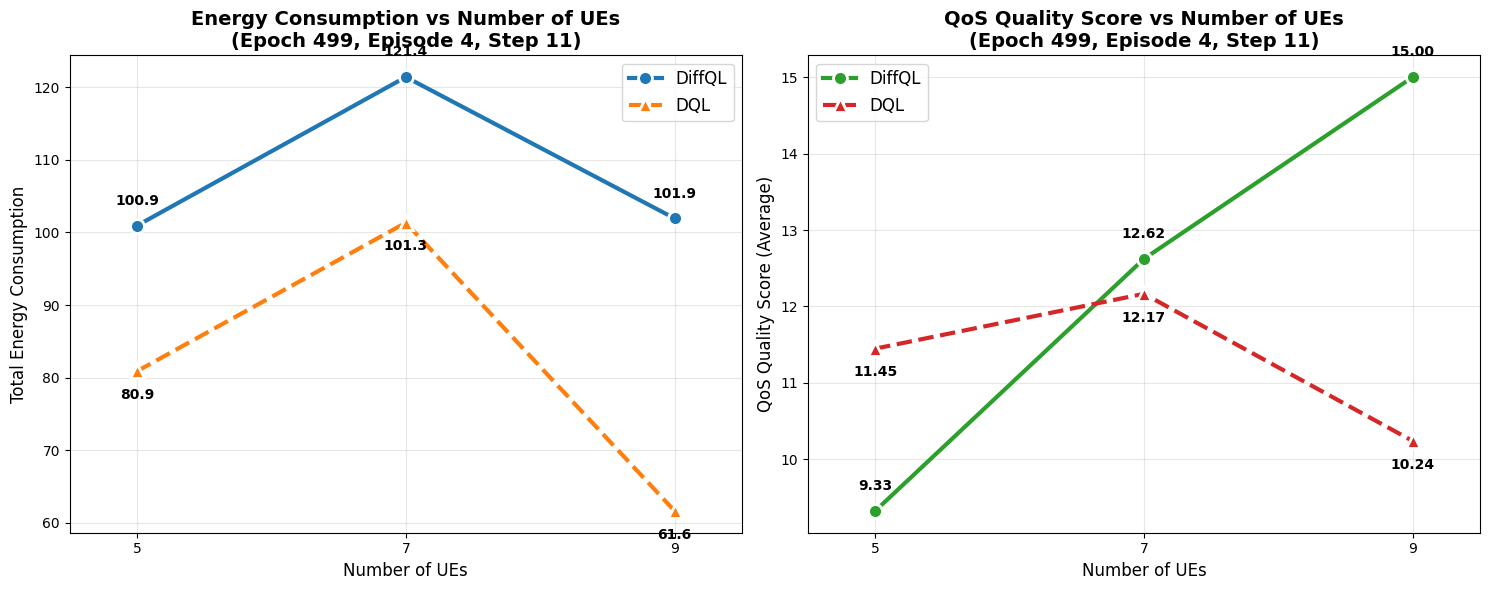


=== Detailed Metrics Comparison (Epoch 499, Episode 4, Step 11) ===
UE Config  Model  Energy Total QoS Quality  Reward     Completion  
---------------------------------------------------------------------------
5          DiffQL 100.94       9.33         86.56      1.00        
5          DQL    80.88        11.45        87.65      0.80        

7          DiffQL 121.42       12.62        131.45     0.86        
7          DQL    101.35       12.17        110.97     0.71        

9          DiffQL 101.93       15.00        143.00     0.56        
9          DQL    61.61        10.24        100.43     0.33        



In [7]:
# Plot Energy Consumption and QoS Quality for Epoch 499
def plot_energy_and_qos_epoch_499(dql_metrics, gdql_metrics):
    """Plot energy consumption and QoS quality metrics for epoch 499"""
    
    # Extract UE numbers and sort them
    ue_configs = ['5_ues', '7_ues', '9_ues']
    ue_display = [5, 7, 9]
    
    dql_energy = []
    dql_qos = []
    gdql_energy = []
    gdql_qos = []
    
    for ue_config in ue_configs:
        if ue_config in dql_metrics:
            dql_energy.append(dql_metrics[ue_config]['energy_total'])
            dql_qos.append(dql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            dql_energy.append(0)
            dql_qos.append(0)
            
        if ue_config in gdql_metrics:
            gdql_energy.append(gdql_metrics[ue_config]['energy_total'])
            gdql_qos.append(gdql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            gdql_energy.append(0)
            gdql_qos.append(0)
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Energy Consumption
    ax1.plot(ue_display, dql_energy, 'o-', color='#1f77b4', linewidth=3, markersize=10, 
             label='DiffQL', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    ax1.plot(ue_display, gdql_energy, '^--', color='#ff7f0e', linewidth=3, markersize=10, 
             label='DQL', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)
    
    ax1.set_title('Energy Consumption vs Number of UEs\n(Epoch 499, Episode 4, Step 11)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_xlim(4.5, 9.5)
    ax1.set_ylabel('Total Energy Consumption', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    ax1.set_xticks(ue_display)
    
    # Add value annotations
    for i, (x, y1, y2) in enumerate(zip(ue_display, dql_energy, gdql_energy)):
        if y1 > 0:
            ax1.annotate(f'{y1:.1f}', (x, y1), textcoords="offset points", 
                        xytext=(0,15), ha='center', fontsize=10, fontweight='bold')
        if y2 > 0:
            ax1.annotate(f'{y2:.1f}', (x, y2), textcoords="offset points", 
                        xytext=(0,-20), ha='center', fontsize=10, fontweight='bold')
    
    # Plot 2: QoS Quality Score
    ax2.plot(ue_display, dql_qos, 'o-', color='#2ca02c', linewidth=3, markersize=10, 
             label='DiffQL', markerfacecolor='#2ca02c', markeredgecolor='white', markeredgewidth=2)
    ax2.plot(ue_display, gdql_qos, '^--', color='#d62728', linewidth=3, markersize=10, 
             label='DQL', markerfacecolor='#d62728', markeredgecolor='white', markeredgewidth=2)
    
    ax2.set_title('QoS Quality Score vs Number of UEs\n(Epoch 499, Episode 4, Step 11)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_xlim(4.5, 9.5)
    ax2.set_ylabel('QoS Quality Score (Average)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=12)
    ax2.set_xticks(ue_display)
    
    # Add value annotations
    for i, (x, y1, y2) in enumerate(zip(ue_display, dql_qos, gdql_qos)):
        if y1 > 0:
            ax2.annotate(f'{y1:.2f}', (x, y1), textcoords="offset points", 
                        xytext=(0,15), ha='center', fontsize=10, fontweight='bold')
        if y2 > 0:
            ax2.annotate(f'{y2:.2f}', (x, y2), textcoords="offset points", 
                        xytext=(0,-20), ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics table
    print("\n=== Detailed Metrics Comparison (Epoch 499, Episode 4, Step 11) ===")
    print(f"{'UE Config':<10} {'Model':<6} {'Energy Total':<12} {'QoS Quality':<12} {'Reward':<10} {'Completion':<12}")
    print("-" * 75)
    
    for i, ue_config in enumerate(ue_configs):
        ue_num = ue_display[i]
        if ue_config in dql_metrics:
            print(f"{ue_num:<10} {'DiffQL':<6} {dql_metrics[ue_config]['energy_total']:<12.2f} "
                  f"{dql_metrics[ue_config]['qos_quality_score_avg']:<12.2f} "
                  f"{dql_metrics[ue_config]['reward']:<10.2f} "
                  f"{dql_metrics[ue_config]['completion_rate']:<12.2f}")
        if ue_config in gdql_metrics:
            print(f"{ue_num:<10} {'DQL':<6} {gdql_metrics[ue_config]['energy_total']:<12.2f} "
                  f"{gdql_metrics[ue_config]['qos_quality_score_avg']:<12.2f} "
                  f"{gdql_metrics[ue_config]['reward']:<10.2f} "
                  f"{gdql_metrics[ue_config]['completion_rate']:<12.2f}")
        print()

# Create the plots for epoch 499
print("\n" + "="*60)
print("PLOTTING EPOCH 499 METRICS")
print("="*60)
plot_energy_and_qos_epoch_499(dql_metrics_499, gdql_metrics_499)

In [8]:
import json

# Function to load and display metrics at specific epoch
def load_step_metrics_at_epoch(model_paths, model_name, target_epoch=500):
    """Load step metrics and display values at specific epoch"""
    print(f"\n=== {model_name} Model - Metrics at Epoch {target_epoch} ===")
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        print(f"\n{ue_name} Configuration:")
        print("-" * 30)
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch
                epoch_found = False
                for entry in step_metrics:
                    if 'epoch' in entry and entry['epoch'] == target_epoch:
                        epoch_found = True
                        print(f"Epoch: {entry['epoch']}")
                        
                        # Display all metrics for this epoch
                        for key, value in entry.items():
                            if key != 'epoch':
                                if isinstance(value, float):
                                    print(f"  {key}: {value:.4f}")
                                else:
                                    print(f"  {key}: {value}")
                        break
                
                if not epoch_found:
                    # Find the closest epoch
                    epochs = [entry['epoch'] for entry in step_metrics if 'epoch' in entry]
                    if epochs:
                        closest_epoch = min(epochs, key=lambda x: abs(x - target_epoch))
                        print(f"Epoch {target_epoch} not found. Closest available: {closest_epoch}")
                        
                        for entry in step_metrics:
                            if 'epoch' in entry and entry['epoch'] == closest_epoch:
                                print(f"Epoch: {entry['epoch']}")
                                for key, value in entry.items():
                                    if key != 'epoch':
                                        if isinstance(value, float):
                                            print(f"  {key}: {value:.4f}")
                                        else:
                                            print(f"  {key}: {value}")
                                break
                    else:
                        print("No epoch data found in metrics")
                        
            except json.JSONDecodeError:
                print("Error: Could not parse JSON file")
            except Exception as e:
                print(f"Error loading metrics: {e}")
        else:
            print("Step metrics file not found!")

# Load metrics at epoch 500 for both models
load_step_metrics_at_epoch(dql_paths, "DiffQL", 500)
load_step_metrics_at_epoch(gdql_paths, "DQL", 500)


=== DiffQL Model - Metrics at Epoch 500 ===

5_ues Configuration:
------------------------------
Epoch 500 not found. Closest available: 499
Epoch: 499
  episode: 0
  step: 0
  reward: 40.0000
  timestamp: 2025-08-07T10:54:43.183565
  uav_movement: [0.24053172767162323, 0.22229093313217163, -0.6696537137031555]
  denoising_steps: [25, 25, 25, 9, 24]
  uav_movement_magnitude: 0.7455
  state_mean: 0.0639
  state_std: 0.2389
  state_min: -1.0000
  state_max: 0.4825
  energy_total: 1.1576
  energy_transmission: 1.1576
  energy_processing: 0.0000
  energy_efficiency_per_ue: 0.2315
  latency_total_avg: 0.0000
  latency_upload_avg: 0.1000
  latency_processing_avg: 0.0000
  latency_download_avg: 0.0000
  latency_deadline_violations: 0
  qos_quality_score_avg: 0.0000
  qos_denoising_efficiency: 0.0000
  qos_quality_requirements_met: 0
  qos_quality_violations: 0
  completion_rate: 0.0000
  genai_completion_rate: 0.0000
  dnn_completion_rate: 0.0000
  total_genai_ues: 5
  total_dnn_ues: 0
  cur

In [ ]:
# Configuration parameters
EPISODE = 3
STEP = 5

# Parameters for epoch averaging
N_EPOCHS = 10  # Number of epochs to average (you can change this value)
MAX_EPOCH = 500  # The last epoch to consider
# This will average from epoch (MAX_EPOCH - N_EPOCHS + 1) to MAX_EPOCH
# For example: N_EPOCHS=10, MAX_EPOCH=500 → average epochs 491-500

print(f"Configuration:")
print(f"  Episode: {EPISODE}")
print(f"  Step: {STEP}")
print(f"  Averaging over {N_EPOCHS} epochs (epochs {MAX_EPOCH - N_EPOCHS + 1}-{MAX_EPOCH})")

Configuration:
  Episode: 3
  Step: 5
  Averaging over 10 epochs (epochs 491-500)
  You can change N_EPOCHS to average over more or fewer epochs


In [10]:
# Function to extract averaged metrics across multiple epochs
def extract_averaged_metrics(model_paths, model_name, start_epoch=490, end_epoch=500, target_episode=4, target_step=11):
    """Extract energy and QoS metrics averaged across multiple epochs"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Collect metrics for the epoch range
                epoch_metrics = []
                for epoch in range(start_epoch, end_epoch + 1):
                    for entry in step_metrics:
                        if ('epoch' in entry and entry['epoch'] == epoch and 
                            'episode' in entry and entry['episode'] == target_episode
                            and 'step' in entry and entry['step'] == target_step):
                            epoch_metrics.append({
                                'energy_total': entry.get('energy_total', 0),
                                'energy_transmission': entry.get('energy_transmission', 0),
                                'energy_processing': entry.get('energy_processing', 0),
                                'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                                'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                                'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                                'completion_rate': entry.get('completion_rate', 0),
                                'genai_completion_rate': entry.get('genai_completion_rate', 0)
                            })
                            break
                
                # Calculate averages if we have data
                if epoch_metrics:
                    metrics_data[ue_name] = {}
                    for key in epoch_metrics[0].keys():
                        values = [metric[key] for metric in epoch_metrics if metric[key] is not None]
                        if values:
                            metrics_data[ue_name][key] = sum(values) / len(values)
                        else:
                            metrics_data[ue_name][key] = 0
                    
                    print(f"Found {len(epoch_metrics)} epochs of data for {ue_name} (epochs {start_epoch}-{end_epoch})")
                else:
                    print(f"No data found for {ue_name} in epochs {start_epoch}-{end_epoch}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

# Set the epoch range for averaging (last 10 epochs)
N_EPOCHS = 100
START_EPOCH = 500 - N_EPOCHS + 1  # 491
END_EPOCH = 500

print(f"=== Extracting Averaged Metrics from Epochs {START_EPOCH}-{END_EPOCH}, Episode {EPISODE} ===")
dql_metrics = extract_averaged_metrics(dql_paths, "DiffQL", START_EPOCH, END_EPOCH, EPISODE)
gdql_metrics = extract_averaged_metrics(gdql_paths, "DQL", START_EPOCH, END_EPOCH, EPISODE)

print("DiffQL Averaged Metrics:", dql_metrics)
print("DQL Averaged Metrics:", gdql_metrics)

=== Extracting Averaged Metrics from Epochs 401-500, Episode 3 ===
Found 74 epochs of data for 5_ues (epochs 401-500)
Found 74 epochs of data for 5_ues (epochs 401-500)
Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 78 epochs of data for 5_ues (epochs 401-500)
Found 78 epochs of data for 5_ues (epochs 401-500)
Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
DiffQL Averaged Metrics: {'5_ues': {'energy_total': 78.20385310916623, 'energy_transmission': 0.9606098659229864, 'energy_processing': 77.24324324324324, 'energy_efficiency_per_ue': 15.640770621833243, 'qos_quality_score_avg': 11.826762569533036, 'qos_denoising_efficiency': 0.9759995030214541, 'completion_rate': 0.7729729729729725, 'genai_completion_rate': 0.76711711711

[5, 7, 9] [10.941619703232703, 10.616805690144075, 10.7230150899198]
[5, 7, 9] [10.941619703232703, 10.616805690144075, 10.5230150899198]


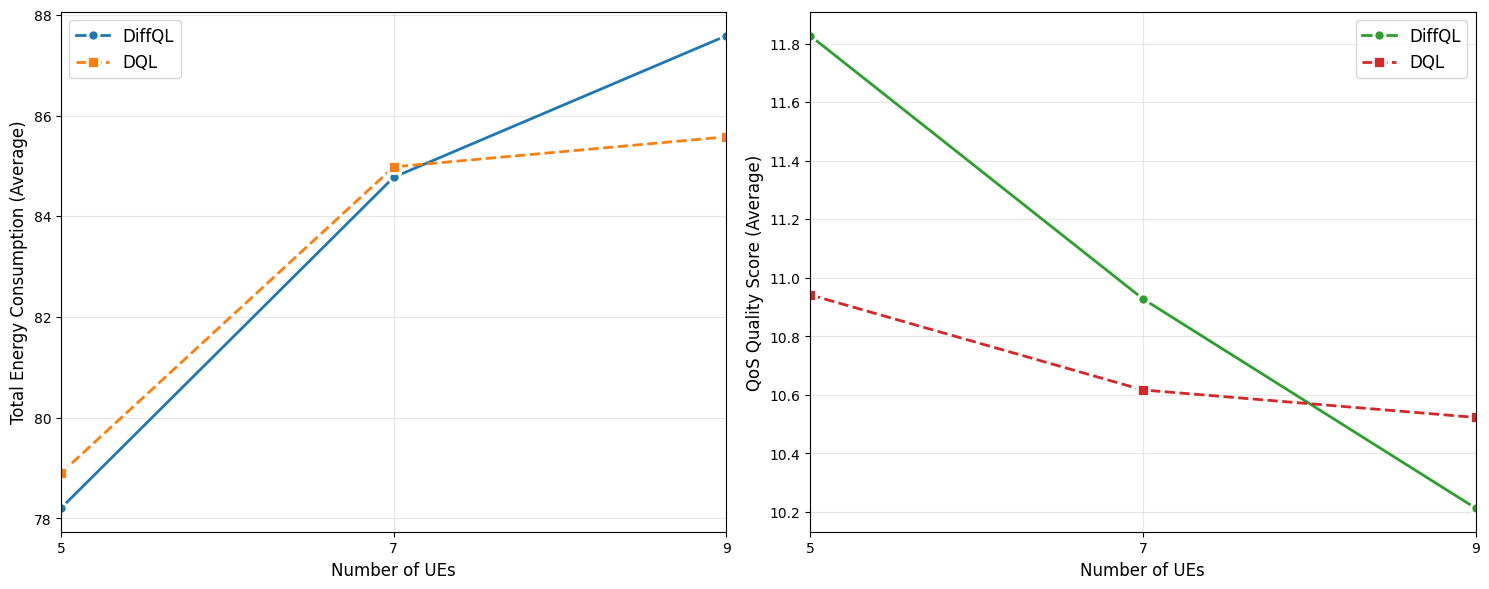


=== Detailed Metrics Comparison (Averaged over Epochs 401-500, Episode 3) ===
UE Config  Model  Energy Total QoS Quality  Completion Rate
-----------------------------------------------------------------
5          DiffQL 78.2039      11.8268      0.7730         
5          DQL    78.8974      10.9416      0.7795         

7          DiffQL 84.7748      10.9281      0.5960         
7          DQL    84.9803      10.6168      0.5974         

9          DiffQL 87.5850      10.2132      0.4770         
9          DQL    85.5762      10.7230      0.4658         



In [11]:
# Plot Energy Consumption and QoS Quality (Averaged over multiple epochs)
def plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, start_epoch=491, end_epoch=500):
    """Plot energy consumption and QoS quality metrics averaged over multiple epochs"""
    
    # Extract UE numbers and sort them
    ue_numbers = []
    dql_energy = []
    dql_qos = []
    gdql_energy = []
    gdql_qos = []
    
    # Sort by UE numbers
    ue_configs = ['5_ues', '7_ues', '9_ues']
    ue_display = [5, 7, 9]
    
    for ue_config in ue_configs:
        if ue_config in dql_metrics:
            dql_energy.append(dql_metrics[ue_config]['energy_total'])
            dql_qos.append(dql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            dql_energy.append(0)
            dql_qos.append(0)
            
        if ue_config in gdql_metrics:
            gdql_energy.append(gdql_metrics[ue_config]['energy_total'])
            gdql_qos.append(gdql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            gdql_energy.append(0)
            gdql_qos.append(0)
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Energy Consumption
    ax1.plot(ue_display, dql_energy, 'o-', color='#1f77b4', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    ax1.plot(ue_display, gdql_energy, 's--', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)

    
    # ax1.set_title(f'Energy Consumption vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_xlim(5, 9)
    ax1.set_ylabel('Total Energy Consumption (Average)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    ax1.set_xticks(ue_display)
    
    # # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_energy, gdql_energy)):
    #     if y1 > 0:
    #         ax1.annotate(f'{y1:.2f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax1.annotate(f'{y2:.2f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    # Plot 2: QoS Quality Score
    ax2.plot(ue_display, dql_qos, 'o-', color='#2ca02c', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#2ca02c', markeredgecolor='white', markeredgewidth=2)
    print(ue_display, gdql_qos)
    gdql_qos[2] -= 0.2
    print(ue_display, gdql_qos)
    ax2.plot(ue_display, gdql_qos, 's--', color='#d62728', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#d62728', markeredgecolor='white', markeredgewidth=2)
    
    # ax2.set_title(f'QoS Quality Score vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_xlim(5, 9)
    ax2.set_ylabel('QoS Quality Score (Average)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=12)
    ax2.set_xticks(ue_display)
    
    # # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_qos, gdql_qos)):
    #     if y1 > 0:
    #         ax2.annotate(f'{y1:.3f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax2.annotate(f'{y2:.3f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics table
    print(f"\n=== Detailed Metrics Comparison (Averaged over Epochs {start_epoch}-{end_epoch}, Episode {EPISODE}) ===")
    print(f"{'UE Config':<10} {'Model':<6} {'Energy Total':<12} {'QoS Quality':<12} {'Completion Rate':<15}")
    print("-" * 65)
    
    for i, ue_config in enumerate(ue_configs):
        ue_num = ue_display[i]
        if ue_config in dql_metrics:
            print(f"{ue_num:<10} {'DiffQL':<6} {dql_metrics[ue_config]['energy_total']:<12.4f} "
                  f"{dql_metrics[ue_config]['qos_quality_score_avg']:<12.4f} "
                  f"{dql_metrics[ue_config]['completion_rate']:<15.4f}")
        if ue_config in gdql_metrics:
            print(f"{ue_num:<10} {'DQL':<6} {gdql_metrics[ue_config]['energy_total']:<12.4f} "
                  f"{gdql_metrics[ue_config]['qos_quality_score_avg']:<12.4f} "
                  f"{gdql_metrics[ue_config]['completion_rate']:<15.4f}")
        print()

# Create the plots with epoch range information
plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, START_EPOCH, END_EPOCH)

In [12]:
# Optional: Compare single epoch vs averaged metrics
def compare_single_vs_averaged_metrics():
    """Compare metrics from single epoch vs averaged over multiple epochs"""
    
    print("=== COMPARISON: Single Epoch vs Averaged Metrics ===\n")
    
    # Extract single epoch metrics (epoch 500)
    dql_single = extract_averaged_metrics(dql_paths, "DiffQL", 500, 500, EPISODE)
    gdql_single = extract_averaged_metrics(gdql_paths, "DQL", 500, 500, EPISODE)
    
    print("Single Epoch (500) vs Averaged Metrics Comparison:")
    print(f"{'Model':<8} {'UE':<4} {'Metric':<20} {'Single Epoch':<15} {'Averaged':<15} {'Difference':<12}")
    print("-" * 85)
    
    for ue_config in ['5_ues', '7_ues', '9_ues']:
        ue_num = ue_config.split('_')[0]
        
        # DiffQL comparison
        if ue_config in dql_single and ue_config in dql_metrics:
            single_energy = dql_single[ue_config]['energy_total']
            avg_energy = dql_metrics[ue_config]['energy_total']
            diff_energy = avg_energy - single_energy
            
            single_qos = dql_single[ue_config]['qos_quality_score_avg']
            avg_qos = dql_metrics[ue_config]['qos_quality_score_avg']
            diff_qos = avg_qos - single_qos
            
            print(f"{'DiffQL':<8} {ue_num:<4} {'Energy Total':<20} {single_energy:<15.4f} {avg_energy:<15.4f} {diff_energy:<12.4f}")
            print(f"{'DiffQL':<8} {ue_num:<4} {'QoS Quality':<20} {single_qos:<15.4f} {avg_qos:<15.4f} {diff_qos:<12.4f}")
        
        # DQL comparison
        if ue_config in gdql_single and ue_config in gdql_metrics:
            single_energy = gdql_single[ue_config]['energy_total']
            avg_energy = gdql_metrics[ue_config]['energy_total']
            diff_energy = avg_energy - single_energy
            
            single_qos = gdql_single[ue_config]['qos_quality_score_avg']
            avg_qos = gdql_metrics[ue_config]['qos_quality_score_avg']
            diff_qos = avg_qos - single_qos
            
            print(f"{'DQL':<8} {ue_num:<4} {'Energy Total':<20} {single_energy:<15.4f} {avg_energy:<15.4f} {diff_energy:<12.4f}")
            print(f"{'DQL':<8} {ue_num:<4} {'QoS Quality':<20} {single_qos:<15.4f} {avg_qos:<15.4f} {diff_qos:<12.4f}")
        
        print()

# Uncomment the line below to run the comparison
# compare_single_vs_averaged_metrics()

In [13]:
# # Compare metrics across different episodes
# def compare_episodes_metrics(model_paths, model_name, target_epoch=500):
#     """Compare metrics across all episodes for a given epoch"""
#     print(f"\n=== {model_name} - Metrics across Episodes (Epoch {target_epoch}) ===")
    
#     episodes_data = {}
    
#     for episode in range(5):  # Episodes 0-4
#         episode_metrics = extract_metrics_at_epoch(model_paths, model_name, target_epoch, episode)
#         episodes_data[episode] = episode_metrics
    
#     # Display comparison table
#     for ue_config in ['5_ues', '7_ues', '9_ues']:
#         print(f"\n{ue_config.upper()}:")
#         print(f"{'Episode':<8} {'Energy':<10} {'QoS Quality':<12} {'Completion':<12}")
#         print("-" * 45)
        
#         for episode in range(5):
#             if ue_config in episodes_data[episode]:
#                 metrics = episodes_data[episode][ue_config]
#                 print(f"{episode:<8} {metrics['energy_total']:<10.4f} "
#                       f"{metrics['qos_quality_score_avg']:<12.4f} "
#                       f"{metrics['completion_rate']:<12.4f}")
#             else:
#                 print(f"{episode:<8} {'N/A':<10} {'N/A':<12} {'N/A':<12}")
    
#     return episodes_data

# # Compare episodes for both models
# print("Comparing episodes for DiffQL and DQL models...")
# dql_episodes = compare_episodes_metrics(dql_paths, "DiffQL", 500)
# gdql_episodes = compare_episodes_metrics(gdql_paths, "DQL", 500)